In [1]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding_tokenizer, compute_df_feature, encode_df_feature
from copy import deepcopy

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "time_cos", "time_sin", "norm_volume"]
SEQUENCE_SIZE = 60
VOLATILITY_SCALE = 1.
SAVE_DIR = "weight"
ENCODER_DEPTH = 4
EMBEDDING_DIM = [4, 8, 4, 4, 4, 4] # 8 for InstrumentID to get better clustering

dataset = get_all_dataset(dir="equities_trade")

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = load_tokenizer(path="tokenizer.json") 

raw_data = deepcopy(dataset) # we need it for next ceil
dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding_tokenizer(tokenizer, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)

print("[TEST] ", get_num_embedding_tokenizer(tokenizer, CATEGORIAL_COLUMNS))
dataset


Found 6 files in directory
👾 Load 6427974 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │
│ 000000000Z ┆ 000000Z    ┆

MifidInstrumentID,delta_event_ts,delta_trading_ts,delta_publication_ts,log_return,log_volume,norm_log_return,norm_volume,TradeType,MmtMarketMechanism,MmtTradingMode,MmtAlgorithmicIndicator,Venue,event_ts,time_cos,time_sin
i32,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[i32],list[i32],list[i32],list[i32],list[i64],list[f64],list[f64]
530,"[17.921431, 0.0, … 23.11202]","[17.921431, 0.0, … 23.11202]","[17.921432, 0.0, … 23.11202]","[-0.005571, 0.0, … 0.008253]","[2.079442, 4.234107, … 0.693147]","[-0.003909, 0.001111, … 0.008253]","[-1.099037, 0.85194, … -0.738833]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 1]","[1, 1, … 0]","[2, 2, … 2]","[1774019454640317, 1774019454640317, … 1773330144603362]","[0.819726, 0.819726, … -0.713587]","[-0.572756, -0.572756, … 0.700567]"
554,"[0.0, 21.642877, … 0.0]","[0.0, 21.642877, … 0.0]","[0.0, 21.642877, … 0.0]","[-0.009901, 0.048553, … -0.005141]","[9.578173, 1.386294, … 9.818637]","[-0.009901, 0.043698, … 0.001345]","[3.381771, -4.185739, … 0.930462]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 1]","[1, 0, … 1]","[2, 2, … 2]","[1773831135401327, 1773833643716028, … 1773329941747983]","[-0.007349, 0.48616, … -0.684331]","[-0.999973, -0.87387, … 0.729171]"
286,"[16.911931, 17.223653, … 0.0]","[16.911931, 17.223653, … 0.0]","[16.911916, 17.223653, … 0.0]","[0.002621, -0.002621, … 0.0]","[5.303305, 5.488938, … 4.369448]","[0.002359, -0.002621, … -0.000257]","[0.733217, 0.968098, … 1.55211]","[7, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773907245799387, 1773907276008454, … 1773333309481413]","[0.085503, 0.079321, … -0.992339]","[0.996338, 0.996849, … 0.123549]"
18,"[20.140956, 0.0, … 0.0]","[20.140956, 0.0, … 0.0]","[20.140956, 0.693147, … 0.0]","[0.0, 0.0, … 0.0]","[9.511333, 8.778018, … 13.102165]","[-0.009531, -0.009531, … 0.0]","[-2.834946, -3.065518, … 1.820934]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[1, 1, … 0]","[2, 2, … 2]","[1773907972824639, 1773907972824639, … 1773333310187925]","[-0.064477, -0.064477, … -0.992461]","[0.997919, 0.997919, … 0.122564]"
140,"[0.0, 22.902802, … 25.180262]","[0.0, 22.902802, … 25.180262]","[0.0, 22.902802, … 25.180262]","[0.0, 0.0, … 0.034133]","[6.035481, 7.313887, … 1.098612]","[0.008701, -0.011212, … 0.015767]","[1.373966, 2.553955, … -3.747393]","[4, 4, … 4]","[0, 0, … 0]","[4, 3, … 0]","[1, 0, … 1]","[1, 1, … 1]","[1773829805011099, 1773838647216940, … 1773243009466515]","[-0.8507, -0.303803, … 0.090444]","[0.525652, -0.952735, … 0.995902]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
500,"[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[2.397895, 2.397895]","[-0.00113, -0.008803]","[-0.502022, -0.437359]","[4, 4]","[0, 0]","[0, 0]","[1, 0]","[1, 1]","[1773415824646109, 1773415824646109]","[1.0, 1.0]","[0.0, 0.0]"
375,"[18.398256, 0.0, … 0.0]","[18.398256, 0.0, … 0.0]","[18.398257, 0.0, … 0.693147]","[0.0, 0.001296, … 0.0]","[0.693147, 1.609438, … 3.218876]","[-0.00013, 0.001037, … -0.001038]","[-4.453788, -2.920997, … -2.269007]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 1]","[2, 2, … 2]","[1773907337470476, 1773907337470476, … 1773333309611719]","[0.066476, 0.066476, … -0.992374]","[0.997788, 0.997788, … 0.123265]"
98,"[19.277687, 19.127297, … 19.015528]","[19.277687, 19.127297, … 19.015528]","[19.277687, 19.127297, … 19.015528]","[0.117783, 0.0, … 0.09531]","[10.308986, 12.542548, … 11.512935]","[0.117783, 0.0, … 0.09531]","[-2.207702, -0.109884, … 0.995783]","[7, 4, … 7]","[0, 0, … 0]","[1, 1, … 1]","[1, 1, … 1]","[2, 2, … 2]","[1773908207517139, 1773908410229108, … 1773332954831404]","[-0.109586, -0.150852, … -0.980315]","[0.993977, 0.988556, … 0.197438]"


100%|██████████| 598/598 [00:12<00:00, 48.56it/s]


MLX buffer init in  43.56400513648987 second
MLX train buffer init in  20.754914045333862
MLX test buffer init in  12.335596799850464
EPOCH 1 --- 


4373it [19:19,  3.77it/s]
1875it [02:23, 13.06it/s]


TRAIN LOSS -173.30732870200066 ||| TEST LOSS -143.80845134277342
EPOCH 2 --- 


4373it [12:20,  5.91it/s]
1875it [02:20, 13.32it/s]


...

TRAIN LOSS -175.9560537732986 ||| TEST LOSS -143.81774904785155
EPOCH 9 --- 


4373it [13:06,  5.56it/s]
1875it [02:22, 13.14it/s]


TRAIN LOSS -175.956028095405 ||| TEST LOSS -143.80837133789063
EPOCH 10 --- 


4373it [12:18,  5.92it/s]
1875it [02:16, 13.73it/s]


TRAIN LOSS -175.95601917321804 ||| TEST LOSS -143.80720595703124


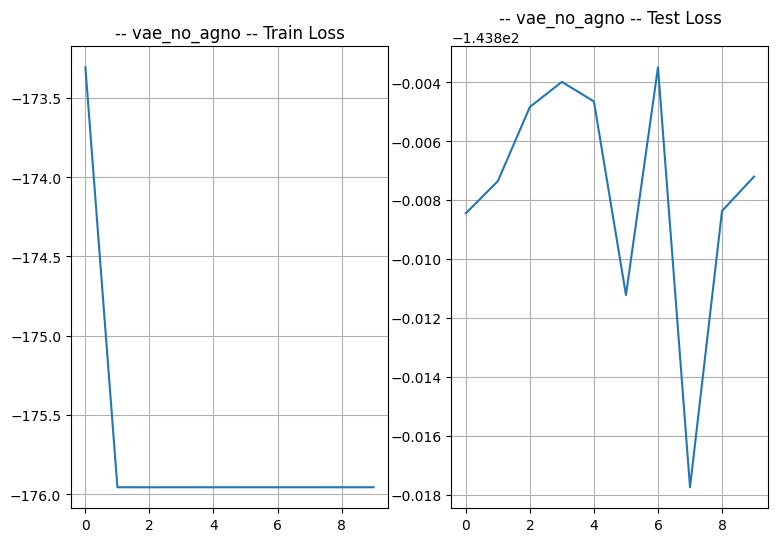

In [ ]:
# First we are going to look at how a VAE + Clustering will output to compare with our price's agnostic model 
from src.processing import get_dataset_volatility
import polars as pl

volatility = get_dataset_volatility(raw_data, tokenizer=tokenizer).group_by("MifidInstrumentID").agg(pl.all())
CATEGORICAL_COLUMNS_NO_AGNO = ["MifidInstrumentID"] # Here we only want our model to reconstruct volatility, so we will ignore other field for now (can be change in the future)
CONTINUOUS_COLUMNS_NO_AGNO = ["Volatility20", "Volatility40", "Volatility80", "log_return"]
EMBEDDING_DIM_NO_AGNO= [8]

import time
from src.config import VAEConfig
from src.vae import VAE
from src.trainer import VAETrainer
from src.processing import get_vae_seq

vae_no_agno_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)


encoder_no_agno_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS_NO_AGNO), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM_NO_AGNO,
                              num_embedding=get_num_embedding(volatility, CATEGORICAL_COLUMNS_NO_AGNO),
                              categorical_col=CATEGORICAL_COLUMNS_NO_AGNO)


optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_no_agno_config, vae_config=vae_no_agno_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=volatility, categorical_col=CATEGORICAL_COLUMNS_NO_AGNO, continous_col=CONTINUOUS_COLUMNS_NO_AGNO, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")

vae_trainer = VAETrainer(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORICAL_COLUMNS_NO_AGNO,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=10,
                  save_dir= SAVE_DIR,
                  model_name="vae_no_agno",
                  plot_chart=True)


** VAE show a great convergeance on train data but seen unstable in test data this can be due to a too small training period (only 11 days), however we are going to look at the cluster the model made with this training period (10 march -> 21 march)

shape: (598, 1)
┌───────────────────┐
│ MifidInstrumentID │
│ ---               │
│ i32               │
╞═══════════════════╡
│ 414               │
│ 545               │
│ 557               │
│ 417               │
│ 140               │
│ …                 │
│ 363               │
│ 512               │
│ 503               │
│ 253               │
│ 256               │
└───────────────────┘
(598, 1)
Best k-mean --> {'score': 0.10794536769390106, 'cluster': 94, 'model': KMeans(n_clusters=94, random_state=22)}
Nb dbs cluster--> 1
{'0': ['FR0000044323', 'FR0011027135', 'FR0014005SB3', 'FR0013462231', 'FR0000060824', 'FR0000038465', 'FR0010112524', 'FR0012185536', 'FR0004030708', 'FR0000066961', 'FR0013143872', 'FR0012613610', 'FR0012127173', 'FR0000062671', 'FR0010307819', 'FR0000033219', 'FR0014011QJ8', 'FR0000061137', 'FR0000064602', 'FR0011184241', 'FR0004034072', 'FR0010131409', 'FR0000121204', 'FR0014008VX5', 'FR00140153H3', 'FR0005691656', 'FR0005175080', 'FR0004052561', 'FR0000037871',

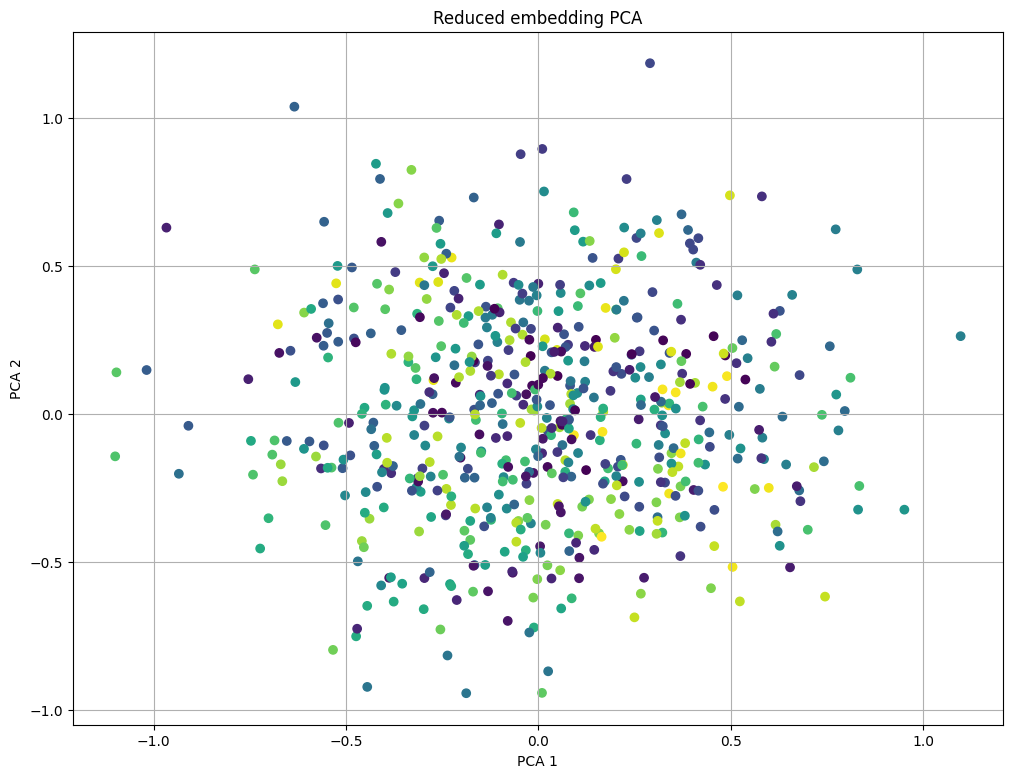

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


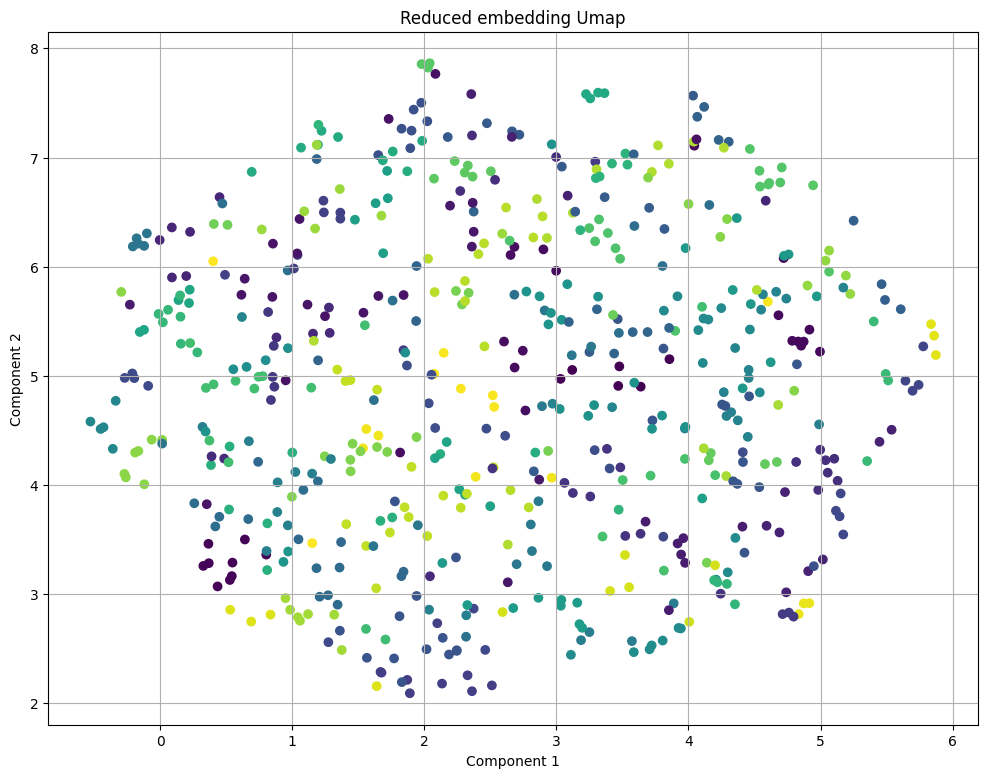

In [ ]:
import src.clustering
import importlib
importlib.reload(src.clustering)
from src.clustering import run_analyse
from src.processing import get_dataset_volatility
from src.config import VAEConfig, EncoderConfig
from src.vae import VAE
import polars as pl

CATEGORICAL_COLUMNS_NO_AGNO = ["MifidInstrumentID"]
CONTINUOUS_COLUMNS_NO_AGNO = ["Volatility20", "Volatility40", "Volatility80", "log_return"]
EMBEDDING_DIM_NO_AGNO= [8]
volatility = get_dataset_volatility(raw_data, tokenizer=tokenizer).group_by("MifidInstrumentID").agg(pl.all())

encoder_no_agno_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS_NO_AGNO), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM_NO_AGNO,
                              num_embedding=get_num_embedding(volatility, CATEGORICAL_COLUMNS_NO_AGNO),
                              categorical_col=CATEGORICAL_COLUMNS_NO_AGNO)

vae_no_agno_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_no_agno_config, vae_config=vae_no_agno_config).load_weights("weight/vae_no_agno.safetensors")
mx.eval(vae_model.parameters())


result = run_analyse(df=volatility, col="MifidInstrumentID", model=vae_model, tokenizer=tokenizer)

the silhouete score (~0.1) isnt optimal also the above plot do not show a great separation beetween asset's, another reason is the PCA is linear and Umap got naive parameters.

-- Further improvement -- 
- Change sequence size
- not include too correlated features (just one volatility on one window)
- include other categorical feature 

====== Volatility Model ===== (Task B)

In [2]:
from src.trainer import VolatilityTrainer
from src.volatility_nn import VolatilityEstimator
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



100%|██████████| 598/598 [01:13<00:00,  8.16it/s]


Target mean -->  0.9091292 +/- 2.4164073
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]
MLX Buffer size --> 6362775
MLX train buffer init in  33.034027099609375
MLX test buffer init in  23.837219715118408
EPOCH 1 --- 


4350it [2:02:56,  1.70s/it]
1865it [10:57,  2.84it/s]


TRAIN LOSS 2.151548365916329 ||| TEST LOSS 1.4327683098194746
EPOCH 2 --- 


4350it [1:47:48,  1.49s/it]
1865it [11:55,  2.61it/s]


...

TRAIN LOSS 2.1465963696337296 ||| TEST LOSS 1.4183056363471391
EPOCH 7 --- 


4350it [2:07:45,  1.76s/it]
1865it [23:47,  1.31it/s]


TRAIN LOSS 2.146361902828874 ||| TEST LOSS 1.4215144534852486
EPOCH 8 --- 


179it [06:22,  2.14s/it]


KeyboardInterrupt: 

======= Variational version ===========

100%|██████████| 598/598 [01:09<00:00,  8.58it/s]


Target mean -->  0.9091292 +/- 2.4164064
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]
MLX Buffer size --> 6362775
MLX train buffer init in  28.782665967941284
MLX test buffer init in  17.199116945266724
EPOCH 1 --- 


4350it [37:26,  1.94it/s]
1865it [05:53,  5.28it/s]


TRAIN LOSS nan ||| TEST LOSS nan
EPOCH 2 --- 


4350it [39:47,  1.82it/s]
1865it [06:41,  4.65it/s]


...

TRAIN LOSS nan ||| TEST LOSS nan
EPOCH 9 --- 


4350it [41:42,  1.74it/s]
1865it [07:28,  4.16it/s]


TRAIN LOSS nan ||| TEST LOSS nan
EPOCH 10 --- 


4350it [46:29,  1.56it/s]
1865it [08:53,  3.50it/s]


TRAIN LOSS nan ||| TEST LOSS nan


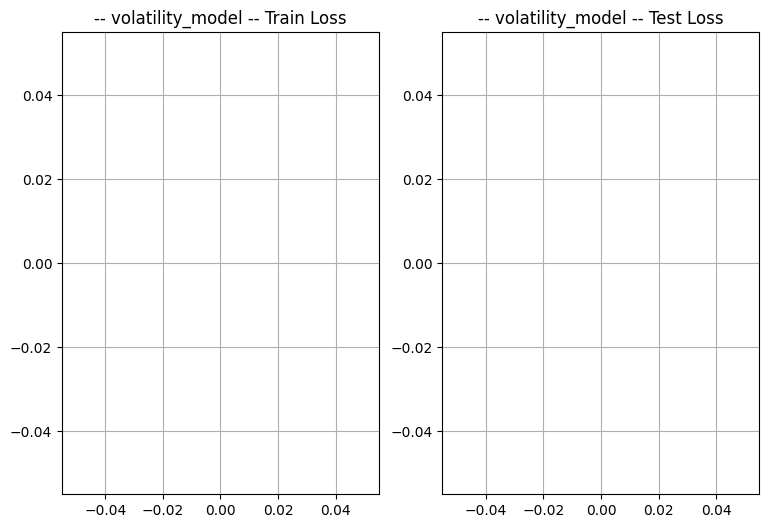

In [2]:

from src.trainer import VolatilityTrainer
from src.volatility_nn import VariationalVolatilityEstimator
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VariationalVolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=10, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



** The Variational result is full of nan, this model is unstable with this state of parameters :     hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2

100%|██████████| 598/598 [01:25<00:00,  7.01it/s]


Target mean -->  0.90912926 +/- 2.4164069
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


100%|██████████| 63628/63628 [02:33<00:00, 414.85it/s]


1 <_top k
View of topk -> shape: (1, 2)
┌─────────┬───────────┐
│ isin_id ┆ score     │
│ ---     ┆ ---       │
│ i64     ┆ f64       │
╞═════════╪═══════════╡
│ 229     ┆ -0.824668 │
└─────────┴───────────┘


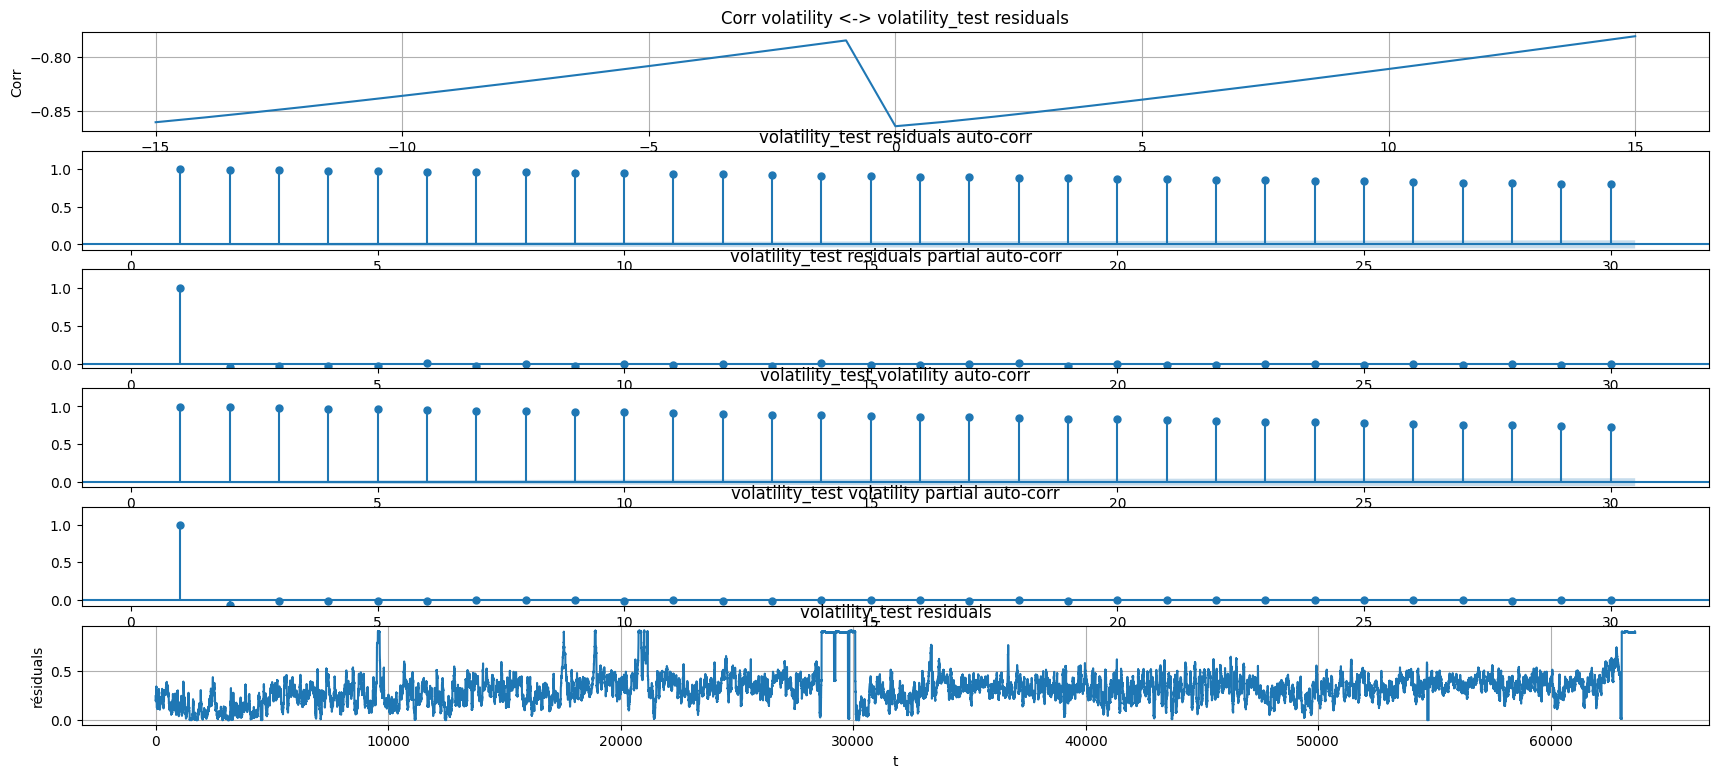

In [8]:
from src.analysis import analyse_volatility_residuals
from src.volatility_nn import VolatilityEstimator
from src.config import VolatilityConfig

TRAIN_SIZE=0.99

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)


volatility_model = VolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
volatility_model.load_weights("weight/volatility_model.safetensors")
mx.eval(volatility_model.parameters())

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)

train_lenght = int(len(buffer)*TRAIN_SIZE)
#buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

#volatility_sequence_train = mx.array([[float(buffer_train[i]["target"]), int(buffer_train[i]["categorical"][0, 1])]for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([[float(buffer_test[i]["target"]), int(buffer_test[i]["categorical"][0, 1])] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_volatility_residuals(model=volatility_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS, save_fig = True, name="volatility_test", top_pct=1.0)
#analyse_volatility_residuals(model=volatility_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_train")


In [9]:
import importlib
import src.analysis
importlib.reload(src.analysis)
from src.analysis import plot_hook_path, get_volatility_model_activation, get_hook_similiarity
import seaborn as sns
import pandas as pd

tree_activation = get_volatility_model_activation(model=volatility_model,
                                                  buffer=buffer_test,
                                                  categorical_col=CATEGORIAL_COLUMNS,
                                                  scale= VOLATILITY_SCALE,
                                                  max_isin=10) # We test only on ten asset 
                                                               # @todo find a way to reduce memory print & augment asset's number
                                                            

score, avg_score = get_hook_similiarity(tree=tree_activation, top_layer=0.3)
print("avg score->", avg_score)
print("score->", score)

score_df = pd.DataFrame(score, columns=list(tree_activation.keys()), index=list(tree_activation.keys()))
sns.heatmap(score_df, annot=True)



 71%|███████▏  | 45349/63628 [00:22<00:09, 1992.52it/s]


RuntimeError: [metal::malloc] Resource limit (499000) exceeded.

===========VAE MODEL===========

In [ ]:
#import importlib
#import src.vae
#importlib.reload(src.vae)
import time
from src.config import VAEConfig
from src.vae import VAE
from src.trainer import VAETrainer
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")
vae_trainer = VAETrainer(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORIAL_COLUMNS,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=10,
                  save_dir= SAVE_DIR,
                  model_name="vae",
                  plot_chart=True)


100%|██████████| 598/598 [00:16<00:00, 36.70it/s]


MLX buffer init in  52.89857792854309 second
MLX train buffer init in  16.595666885375977
MLX test buffer init in  9.667109251022339
EPOCH 1 --- 


1431it [20:06,  1.07it/s]

** The VAE without the volatility features got a great convergeance (better than the VAE with the volatility input we saw at the begining) **
** Note: the convergeance was fast, this mean the model maybe doesn't need this much complexity (4 layers encoder block) **

100%|██████████| 598/598 [01:22<00:00,  7.28it/s]


Target mean -->  0.9091285 +/- 2.4164064
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


100%|██████████| 31814/31814 [01:10<00:00, 450.80it/s]
/Users/arseneducrocq/miniconda3/envs/ls_env/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/arseneducrocq/miniconda3/envs/ls_env/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


4 <_top k
View of topk -> shape: (4, 2)
┌─────────┬───────────┐
│ isin_id ┆ score     │
│ ---     ┆ ---       │
│ i64     ┆ f64       │
╞═════════╪═══════════╡
│ 262     ┆ NaN       │
│ 497     ┆ 0.152129  │
│ 515     ┆ -0.153415 │
│ 357     ┆ -0.316932 │
└─────────┴───────────┘


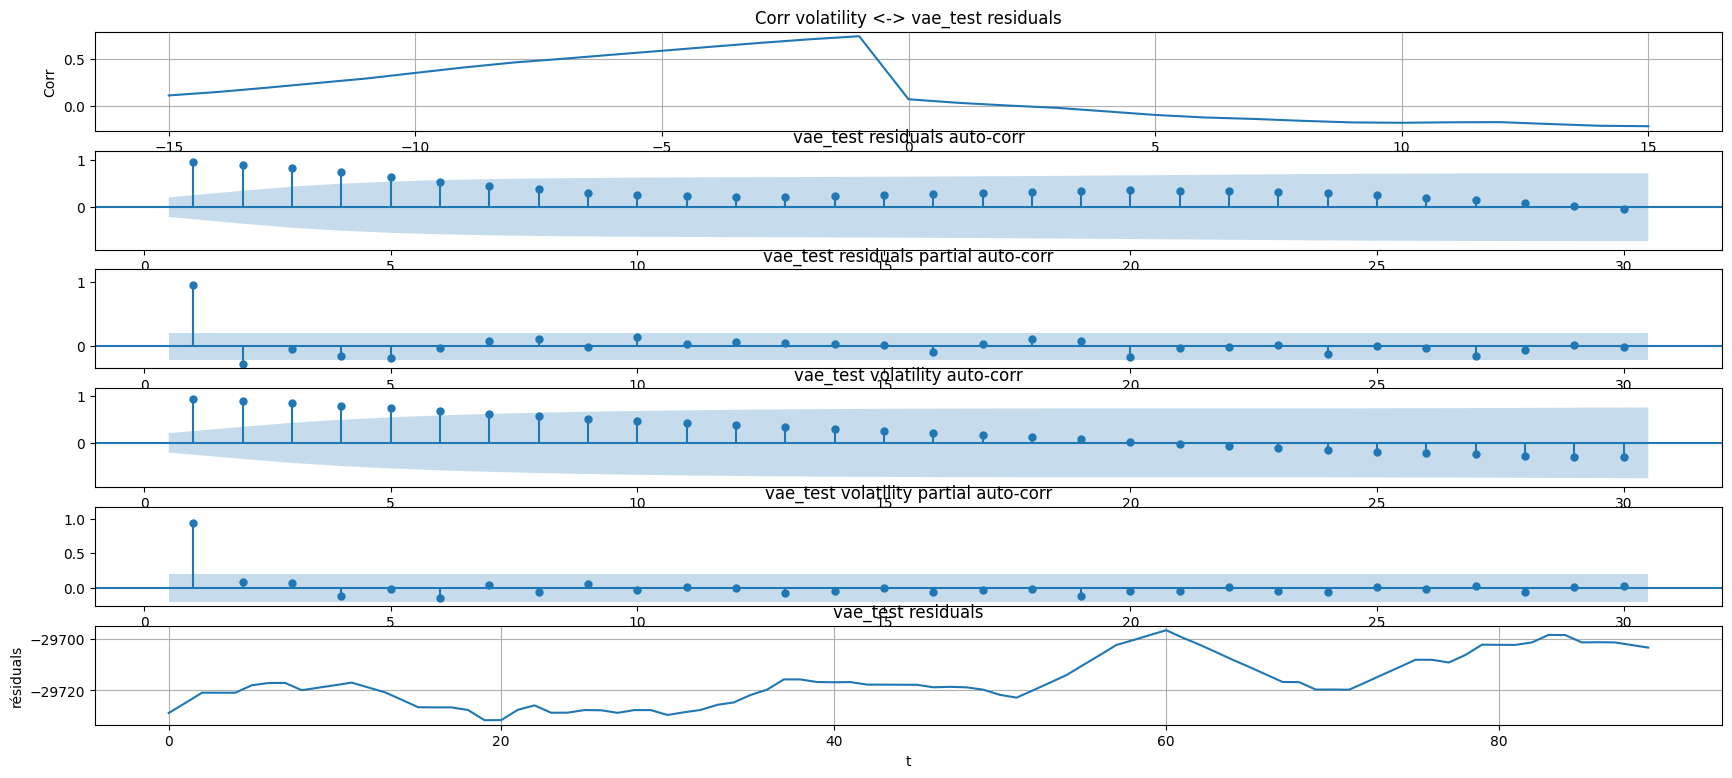

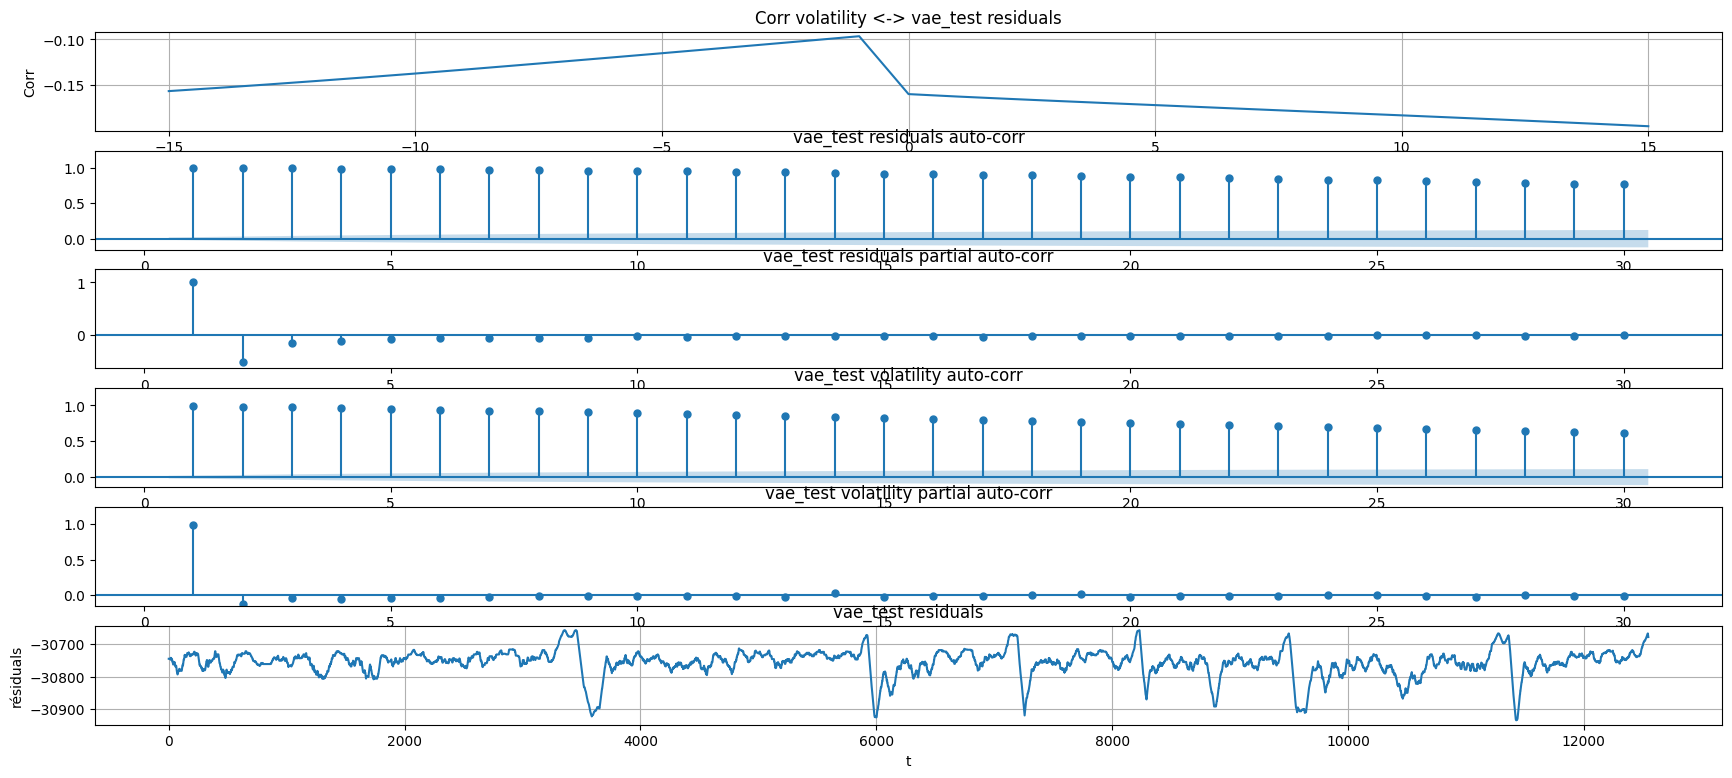

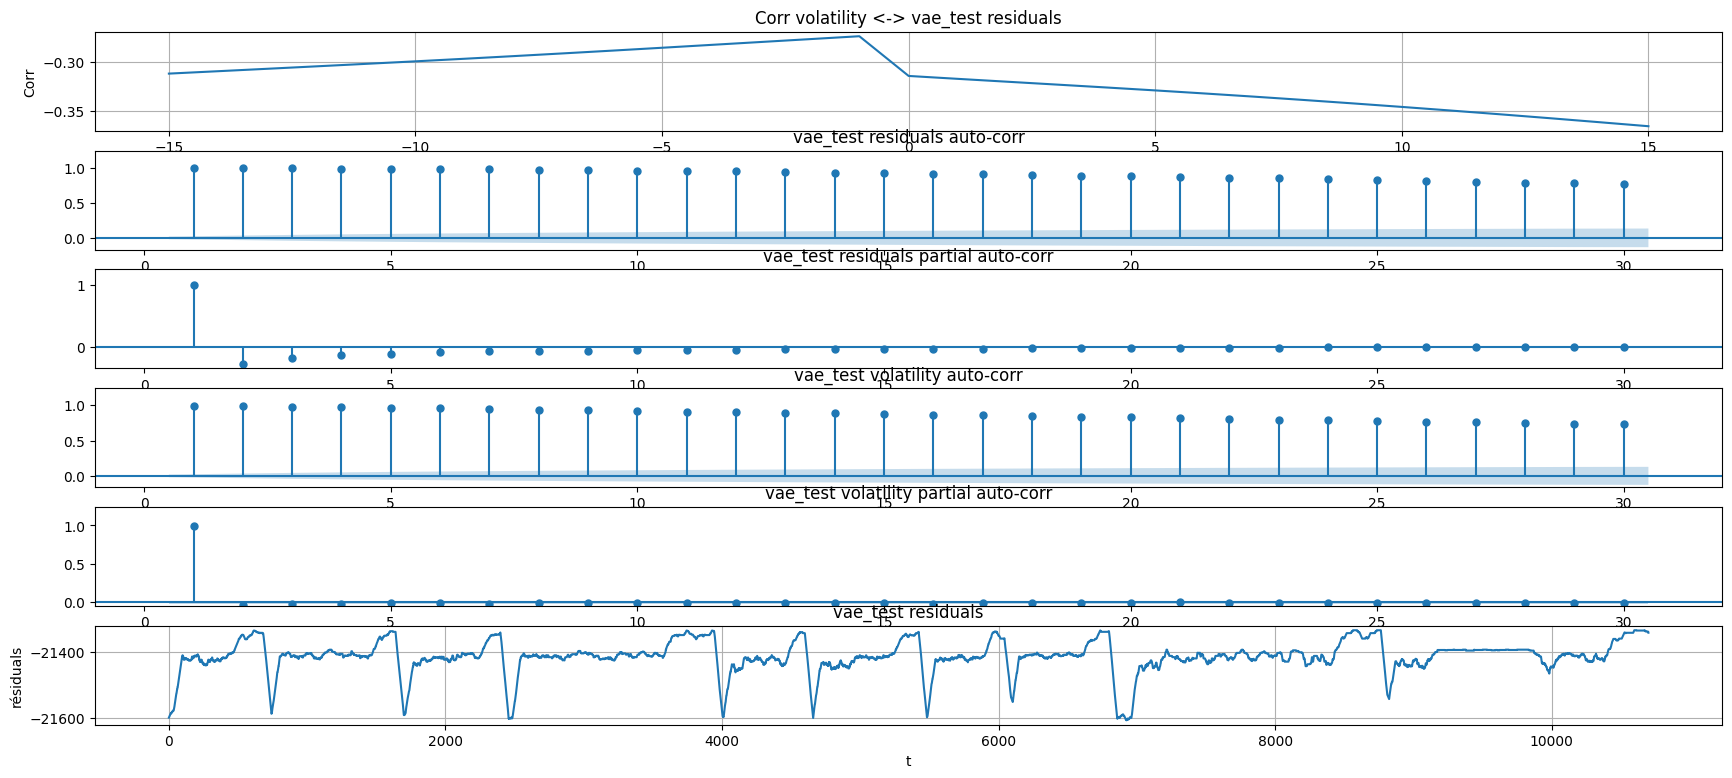

NameError: name 'volatility_sequence_train' is not defined

In [ ]:
from src.analysis import analyse_vae_residuals
from src.vae import VAE
from src.config import VAEConfig
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())
TRAIN_SIZE=0.995

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])


volatility_sequence_train = mx.array([[float(buffer_train[i]["target"]), int(buffer_train[i]["categorical"][0, 1])]for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([[float(buffer_test[i]["target"]), int(buffer_test[i]["categorical"][0, 1])] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_vae_residuals(model=vae_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_test")
analyse_vae_residuals(model=vae_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_train")


In the above sample, we see strong relationship beetween volatility <-> volatility t-1, we can also see that the correlation beetween residual & volatility is ascending at t-1 then decreasing in all of the sample, I will check the prediction's distribution to understand this behavior

==== Prediction Head without encoder pretrained ====

100%|██████████| 598/598 [01:51<00:00,  5.37it/s]


MLX train buffer init in  21.544628143310547
MLX test buffer init in  14.479844093322754
EPOCH 1 --- 


4350it [1:48:59,  1.50s/it]


TEST ACCURACY -  array(49.4103, dtype=float32) %
TRAIN LOSS 0.9990291240571559 ||| TEST LOSS 0.0005424820119515061
EPOCH 2 --- 


4350it [1:49:10,  1.51s/it]


...

TEST ACCURACY -  array(48.736, dtype=float32) %
TRAIN LOSS 0.96333690924206 ||| TEST LOSS 0.0005353758460842073
EPOCH 9 --- 


4350it [2:05:04,  1.73s/it]


TEST ACCURACY -  array(48.9143, dtype=float32) %
TRAIN LOSS 0.9613934557465301 ||| TEST LOSS 0.0005545059684664011
EPOCH 10 --- 


4350it [2:18:53,  1.92s/it]


TEST ACCURACY -  array(49.0126, dtype=float32) %
TRAIN LOSS 0.9597208696535264 ||| TEST LOSS 0.0005363167729228735


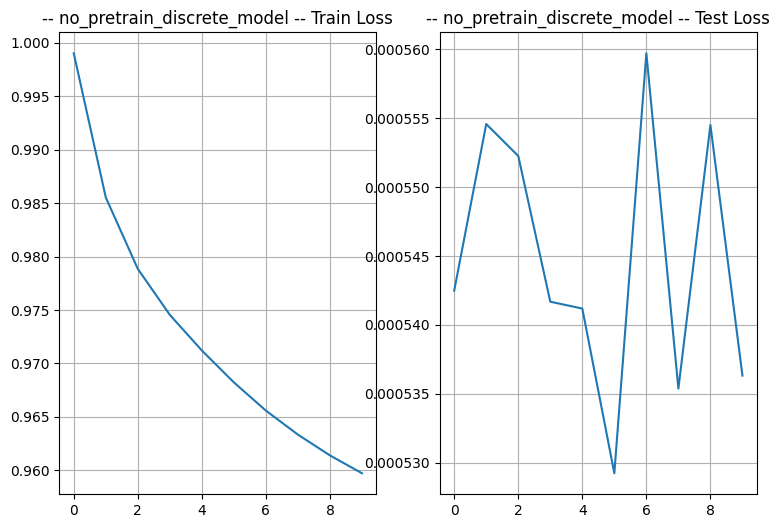

In [7]:
import src.processing
import src.trainer
import importlib
importlib.reload(src.processing)
importlib.reload(src.trainer)
from src.config import DiscreteConfig
from src.volatility_predictor_nn import DiscreteHead
from src.trainer import DiscretizedVolTrainer
from src.processing import get_volatility_discretize_seq

directional_config = DiscreteConfig(
    num_states=3,
    hidden_size = 32,
    activation = ReLU,
    dropout_rate=0.2
)

directional_model = DiscreteHead(encoder_config=encoder_config, dir_config=directional_config)
mx.eval(directional_model.parameters())
directional_optim_config = OptimizerConfig(optimizer_name="adamw", lr=1e-4)

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )
directional_trainer.epoch(n_epoch=10, save_dir=SAVE_DIR, model_name="no_pretrain_discrete_model", plot_chart=True)


==== Prediction Head with VAE encoder ======

In [6]:
from src.config import DiscreteConfig
from src.volatility_predictor_nn import DiscreteHead
from src.trainer import DiscretizedVolTrainer
from src.processing import get_volatility_discretize_seq

directional_config = DiscreteConfig(
    num_states=3,
    hidden_size = 32,
    activation = ReLU,
    dropout_rate=0.2
)

VAE_WEIGHT = "weight/vae.safetensors"
# Load VAE 
import time
from src.config import VAEConfig
from src.vae import VAE


vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
mx.eval(vae_model.parameters())
encoder_weight = vae_model.feature_encoder.state


directional_model_vae = DiscreteHead(encoder_config=encoder_config, 
                                    dir_config=directional_config)

directional_model_vae.encoder.load_weights(encoder_weight)
directional_model_vae.encoder.freeze()

mx.eval(directional_model_vae.parameters())

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )

directional_trainer.epoch(n_epoch=5, save_dir=SAVE_DIR, model_name="vae_pretrain_discrete_model", plot_chart=True)


ValueError: Received 2 parameters not in model: 
categorical_encoder,
layer.

In [ ]:
VOL_WEIGHT = "weight/volatility_model.safetensors"
directional_model_volatility = DiscreteHead(encoder_config=encoder_config, 
                                    dir_config=directional_config,
                                    encoder_weight=VOL_WEIGHT)
directional_model_volatility.encoder.freeze()

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024,
                                           categorical_columns=CATEGORIAL_COLUMNS
                                           )

directional_trainer.epoch(n_epoch=5, 
                          save_dir=SAVE_DIR, 
                          model_name="volatility_pretrain_discrete_model", 
                          plot_chart=True)


===========Clustering & neural net core analyse=============

In [ ]:
# Helper 
import polars as pl
import numpy as np
from src.clustering import plot_pca_cluster, plot_umap, get_best_cluster, get_dbscan_cluster, get_group, get_cluster_intersection


def run_analyse(df: pl.DataFrame, col, model, tokenizer):
    data = df.explode(pl.all().exclude(pl.Int32)).select(col).unique()
    print(data)
    subtokenizer = tokenizer[col]
    data = data.to_numpy()
    data = mx.array(data, dtype=mx.int32)
    print(data.shape)
    model_inpt = {col: data}
    pred = model.feature_encoder.categorical_encoder({col: data})[col]
    mx.eval(pred)
    if len(pred.shape) > 2:
        pred = pred[:,0,:]
    pred = np.array(pred)
    best_km = get_best_cluster(embedding=pred, max_cluster=min(100, np.max(data.shape) - 1))

    print("Best k-mean -->", best_km)
    km_pred = best_km["model"].predict(pred)
    data_np = np.array(data[:, 0])
    cluster = get_group(cluster_pred=km_pred, pred_labels=data_np, sub_tokenizer=subtokenizer)

    best_dbs = get_dbscan_cluster(embedding=pred)
    dbs_pred = best_dbs["pred"]
    dbs_cluster = get_group(cluster_pred=dbs_pred, pred_labels=data_np, sub_tokenizer=subtokenizer)
    print("Nb dbs cluster-->", len(dbs_cluster.keys()))
    print(dbs_cluster)
    plot_pca_cluster(embedding=pred, cluster=km_pred, save_fig=False)
    plot_umap(embedding=pred, cluster=km_pred, save_fig=False)
    return cluster

shape: (9, 1)
┌───────────┐
│ TradeType │
│ ---       │
│ i32       │
╞═══════════╡
│ 6         │
│ null      │
│ 3         │
│ 0         │
│ 4         │
│ 1         │
│ 7         │
│ 2         │
│ 5         │
└───────────┘
(9, 1)
Best k-mean --> {'score': 0.5309972763061523, 'cluster': 2, 'model': KMeans(n_clusters=2, random_state=22)}
Nb dbs cluster--> 3
{np.int64(0): ['41', '25', '1', '33', '20'], np.int64(1): ['39', '39', '40'], np.int64(2): ['105']}


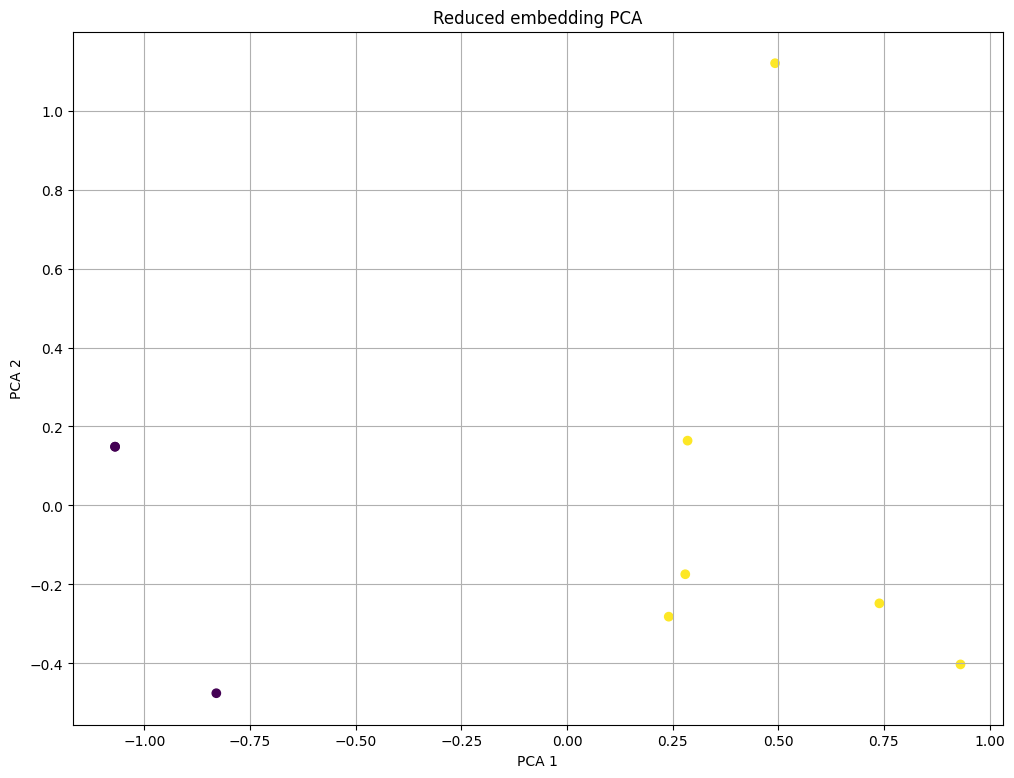

/Users/arseneducrocq/miniconda3/envs/py_env/lib/python3.11/site-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


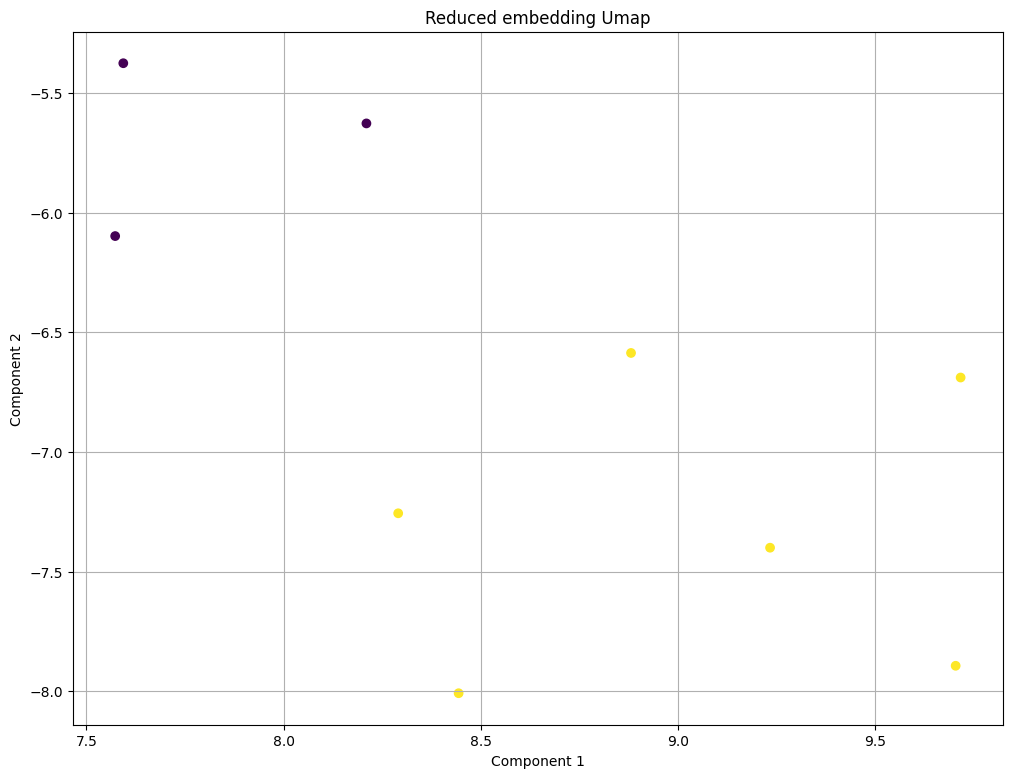

{np.int32(0): ['39', '39', '40'],
 np.int32(1): ['41', '25', '1', '33', '20', '105']}

In [ ]:
import src.clustering
import importlib
importlib.reload(src.clustering)

from src.vae import VAE
from src.config import VAEConfig

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())

# VAE
vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())


cluster = run_analyse(df=dataset, col="TradeType", model=vae_model, tokenizer=tokenizer)
cluster


shape: (598, 1)
┌───────────────────┐
│ MifidInstrumentID │
│ ---               │
│ i32               │
╞═══════════════════╡
│ 146               │
│ 36                │
│ 274               │
│ 539               │
│ 289               │
│ …                 │
│ 515               │
│ 384               │
│ 393               │
│ 244               │
│ 122               │
└───────────────────┘
(598, 1)
Best k-mean --> {'score': 0.0996122807264328, 'cluster': 2, 'model': KMeans(n_clusters=2, random_state=22)}
Nb dbs cluster--> 2
{np.int64(0): ['FR0005691656', 'FR0000065278', 'FR0012968485', 'FR0014008VX5', 'FR0010112524', 'FR00140153H3', 'FR0000121204', 'FR0000060428', 'FR0000035719', 'FR0004030708', 'FR0000075954', 'FR0013006558', 'FR0000064784', 'FR0004034072', 'FR0000060824', 'FR0000062671', 'FR0010483768', 'FR00140059B5', 'FR0000044323', 'FR0000033219', 'FR0000060451', 'FR0000045346', 'FR0010812230', 'FR0012127173', 'FR0004029411', 'FR0013185857', 'FR0005175080', 'FR0011716265', 'FR0000121

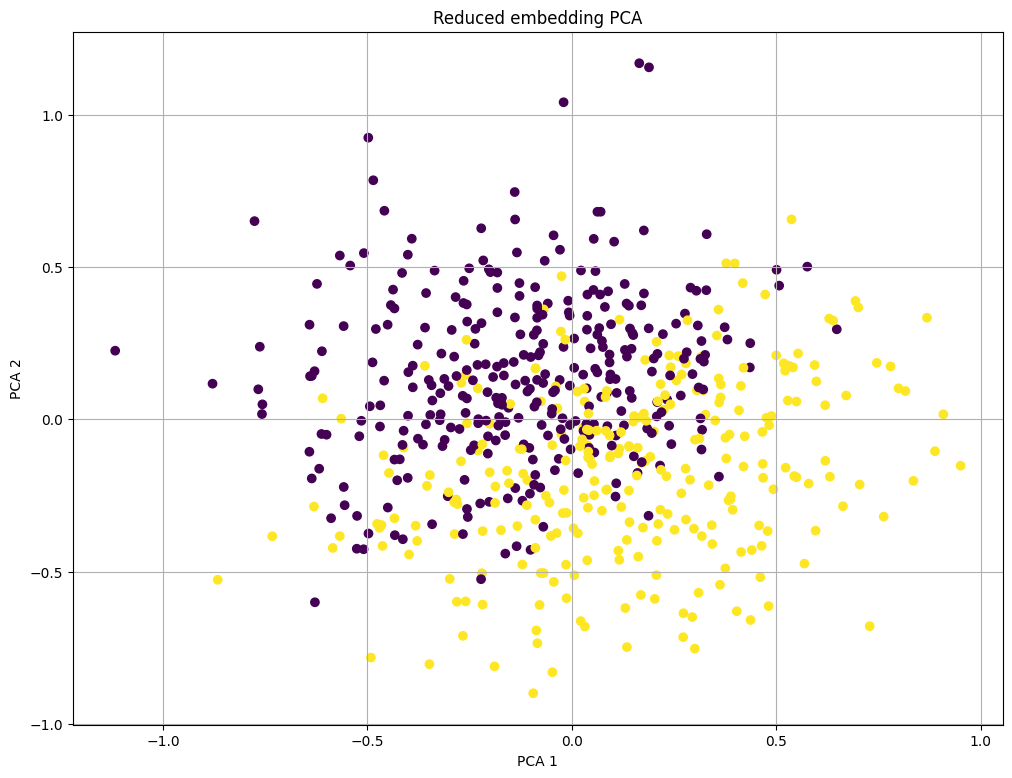

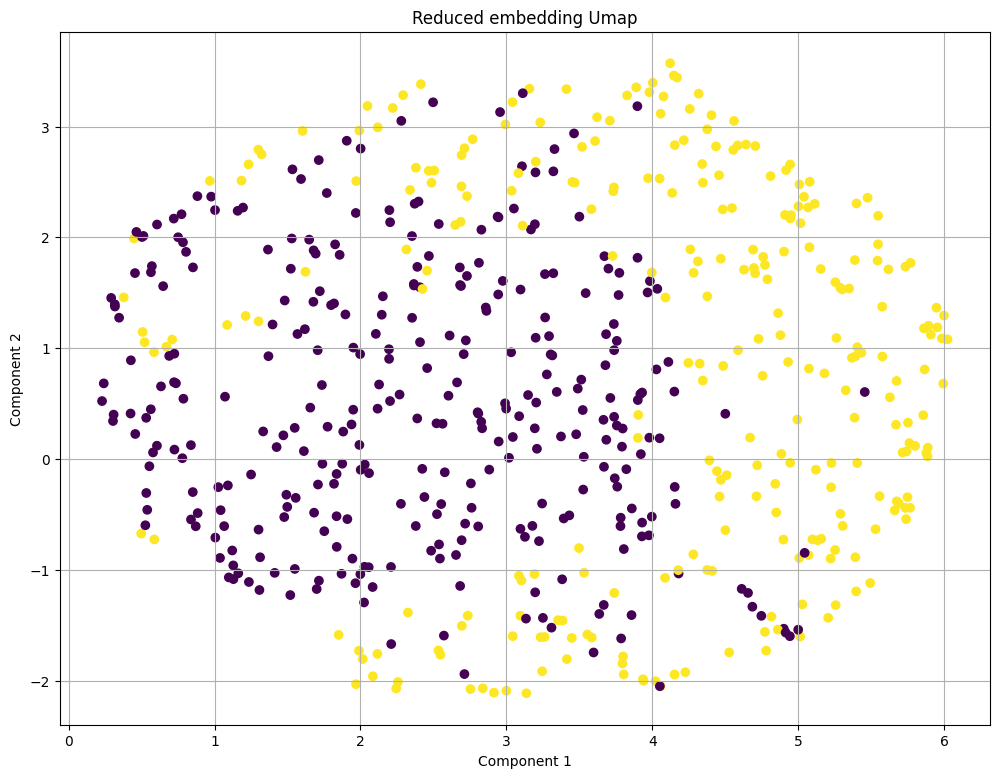

{np.int32(0): ['FR0005691656',
  'FR0000065278',
  'FR0012968485',
  'FR0010112524',
  'FR00140153H3',
  'FR0000121204',
  'FR0000060428',
  'FR0004030708',
  'FR0000075954',
  'FR0004034072',
  'FR0000062671',
  'FR00140059B5',
  'FR0000033219',
  'FR0000060451',
  'FR0010812230',
  'FR0004029411',
  'FR0000121329',
  'FR0006174348',
  'FR0010307819',
  'FR0000061137',
  'FR0004010338',
  'FR0010688465',
  'FR0010131409',
  'FR0013143872',
  'FR0013240934',
  'FR0013462231',
  'FR0010776617',
  'FR0000185506',
  'FR0000033888',
  'FR0011726835',
  'FR0013176526',
  'FR0000130395',
  'FR0000037871',
  'FR0000066961',
  'FR0011184241',
  'FR00140153G5',
  'FR0000064735',
  'FR0000120271',
  'FR0000044943',
  'FR0000066722',
  'FR001400AHX6',
  'FR0000124141',
  'FR0010528059',
  'FR0010291245',
  'FR0000121972',
  'FR0012872141',
  'FR0000052680',
  'FR0014015MS9',
  'FR0011365907',
  'FR0010481960',
  'FR0000125486',
  'FR0000064271',
  'FR0000120321',
  'FR0004050250',
  'FR0010193979

In [ ]:
# Volatility
import src.clustering
import importlib
importlib.reload(src.clustering)

from src.volatility_nn import VolatilityEstimator
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)


vol_model = VolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
vol_model = vol_model.load_weights("weight/volatility_model.safetensors")
mx.eval(vol_model.parameters())

cluster = run_analyse(df=dataset, col="MifidInstrumentID", model=vol_model, tokenizer=tokenizer)
cluster


(598, 1)
Best k-mean --> {'score': 0.09819187223911285, 'cluster': 89, 'model': KMeans(n_clusters=89, random_state=22)}
Nb dbs cluster--> 3
{'0': ['FR0013462231', 'FR0000033219', 'FR0010688465', 'FR0013185857', 'FR0010307819', 'FR0010776617', 'FR0010309096', 'FR0000064784', 'FR0000044323', 'FR0000062671', 'FR0000065278', 'FR0011726835', 'FR00140059B5', 'FR00140153G5', 'FR0012185536', 'FR0000074148', 'FR0013006558', 'FR0000060451', 'FR0010112524', 'FR0010812230', 'FR0005175080', 'FR0004010338', 'FR0005691656', 'FR0013505062', 'FR0000060428', 'FR0004030708', 'FR0000035719', 'FR0011184241', 'FR0013240934', 'FR0000130395', 'FR0012613610', 'FR0006174348', 'FR0014007LW0', 'FR0000061137', 'FR001400OKR3', 'FR0000045346', 'FR0013143872', 'FR0014005WE9', 'FR0000038465', 'FR00140153H3', 'FR0014011QJ8', 'FR0014005SB3', 'FR0000051393', 'FR0000064602', 'FR0011027135', 'FR0010641449', 'FR0004034072', 'FR0000037871', 'FR0000075954', 'FR0000185506', 'FR0000121204', 'FR0000121329', 'FR0000033888', 'FR00

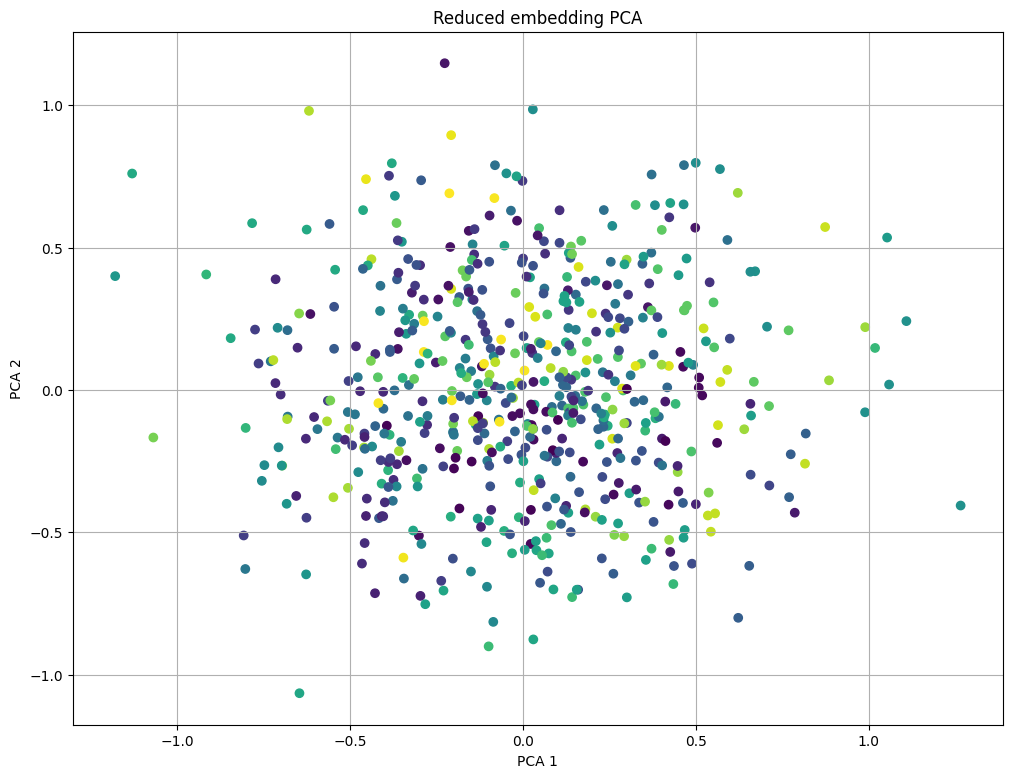

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


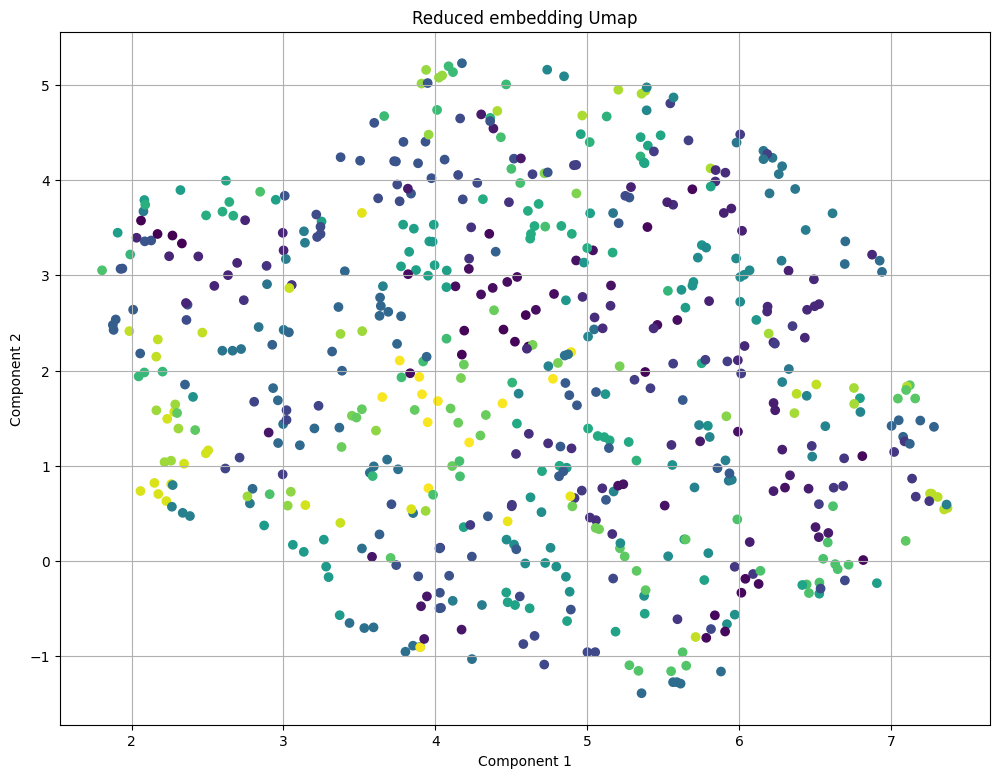

{'0': ['FR0004175842', 'FR001400MDW2', 'FR0000053944', 'FR0006563904'],
 '1': ['FR0000124141',
  'FR0000044471',
  'FR0010204453',
  'FR0000130692',
  'FR0000032658',
  'FR0014005AL0',
  'FR001400DIY6'],
 '2': ['FR0013258662',
  'FR0000039620',
  'FR0004171346',
  'FR0014013HG9',
  'FR0000039232',
  'FR0013479730',
  'FR0012821890',
  'FR0000038184',
  'FR0000074775',
  'FR0010889386',
  'FR0013379484'],
 '3': ['FR0011726835',
  'FR0014011QJ8',
  'FR0010282822',
  'FR0012872141',
  'FR0014004EC4',
  'FR0010313833',
  'FR0013374667',
  'FR0011038348',
  'FR0012612646',
  'FR0010461053',
  'FR0010086371',
  'FR0000076952'],
 '4': ['FR0000045346',
  'FR0010588079',
  'FR0014011ND8',
  'FR0012419307',
  'FR0000130809',
  'FR0000050049',
  'FR0014013Q98',
  'FR0000185514'],
 '5': ['FR001400CM63',
  'FR0010340711',
  'FR0010979377',
  'FR001400SUB7',
  'FR0013384369',
  'FR0011131788'],
 '6': ['FR0014005WE9',
  'FR001400JWR8',
  'FR0000064404',
  'FR0011605617',
  'FR001400M1R1',
  'FR000012

In [6]:
# Volatility
import src.clustering
import importlib
importlib.reload(src.clustering)
from src.clustering import run_analyse


from src.volatility_nn import VolatilityEstimator
from src.config import VolatilityConfig

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)


vol_model = VolatilityEstimator(encoder_config=encoder_config, volatility_config=volatility_config)
vol_model = vol_model.load_weights("weight/volatility_model.safetensors")
mx.eval(vol_model.parameters())

cluster = run_analyse(df=dataset, col="MifidInstrumentID", model=vol_model, tokenizer=tokenizer)
cluster
